## Avoiding rivers during the rainy season

The following code develops a routing function that helps avoid flooding events when routing withinn the Amazon rainforest. It considers river location, seasonality, and road networks.

At first, we develop the routing pipeline without integrating river info, and then weight to avoid rivers.

In [1]:
# load in necessary libraries
import os
import pandas as pd
import geopandas as gpd
from pyprojroot import here
import matplotlib.pyplot as plt
import networkx as nx
from math import radians, sin, cos, sqrt, atan2
from scipy.spatial import KDTree

In [16]:
# read in data
osm_roads = gpd.read_file(here("challenge-docs/challenge-3/roads-osm-paragominas.geojson")) # OSM roads
previsia_roads = gpd.read_file(here("challenge-docs/challenge-3/roads-previsia-2025-paragominas.geojson")) # remotely-sensed roads
rivers = gpd.read_file(here("my-data/para/PA_1505502_RIOS_SIMPLES.shp")).set_crs("EPSG:31983").to_crs(osm_roads.crs) # river network
test = pd.read_csv(here("challenge-docs/challenge-3/test-pairs.csv")) # test pairs provided by hackathon

In [3]:
# same crs?
assert osm_roads.crs == previsia_roads.crs
assert rivers.crs == osm_roads.crs
osm_roads.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
# save test pairs as geo
test_pairs = test.assign( # iterate across appropriate columns and create points
    origin=list(zip(test.origin_lon, test.origin_lat)),
    dest=list(zip(test.dest_lon, test.dest_lat))
)

In [5]:
# filter for OSM roads that are accessible by vehicle
osm_roads_f = osm_roads[~osm_roads['highway'].isin(['track', 'path', 'footway', 'service'])]

#### Helper function: Haversine distance

In [6]:
# haversine distance function (as the crow flies)
def haversine(u, v):
    lon1, lat1 = u
    lon2, lat2 = v
    R = 6371000  # meters
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

### Routing pipeline

In [7]:
# initialize empty graph
G = nx.Graph()

# create nodes
for _, row in osm_roads_f.iterrows(): # loop over every road
    coords = list(row.geometry.coords) # extract line coordinates and save as tuples
    
    # iterate through coords
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())


#### Helper function: Snapping

In [8]:
nodes = list(G.nodes())
tree = KDTree(nodes)

def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist  # now returns distance too

In [9]:
results = []
for _, row in test_pairs.iterrows():
    source, source_dist = snap(row.origin)
    target, target_dist = snap(row.dest)
    try:
        path = nx.shortest_path(G, source=source, target=target, weight='weight')
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        path, length = None, None
    results.append({
        'id': row.id, 'path': path, 'road_distance_m': length,
        'origin_snap_deg': source_dist, 'dest_snap_deg': target_dist
    })

results_df = pd.DataFrame(results)

# convert dest snap to meters
results_df['dest_snap_m'] = results_df['dest_snap_deg'] * 111000

results_df

,id,path,road_distance_m,origin_snap_deg,dest_snap_deg,dest_snap_m
0,par-01,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",47046.634780,0.000214,0.023558,2614.905576
1,par-02,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",64585.638900,0.000214,0.028618,3176.622234
2,par-03,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",61375.744609,0.000214,0.031455,3491.463331
3,par-04,None,NaN,0.000214,0.050589,5615.349448
4,par-05,None,NaN,0.000214,0.050630,5619.894718
5,par-06,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",110433.783646,0.000214,0.022733,2523.345568
6,par-07,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",66855.786671,0.000214,0.028818,3198.852427
7,par-08,None,NaN,0.000214,0.054815,6084.453462
8,par-09,None,NaN,0.000214,0.055747,6187.959412
9,par-10,None,NaN,0.000214,0.050668,5624.107730


**Our metric for "reachable" will be 3km** – meaning workers will have to walk an additional 3km after reaching the point, by road, on a map. By this standard, _ of our points are currently reachable.


## Integrating rivers

In [18]:
# Find road segments that intersect any river
crossings = gpd.sjoin(osm_roads_f, rivers, predicate="intersects", how="inner")
print(len(crossings), "road segments cross a river")

1629 road segments cross a river


<Axes: >

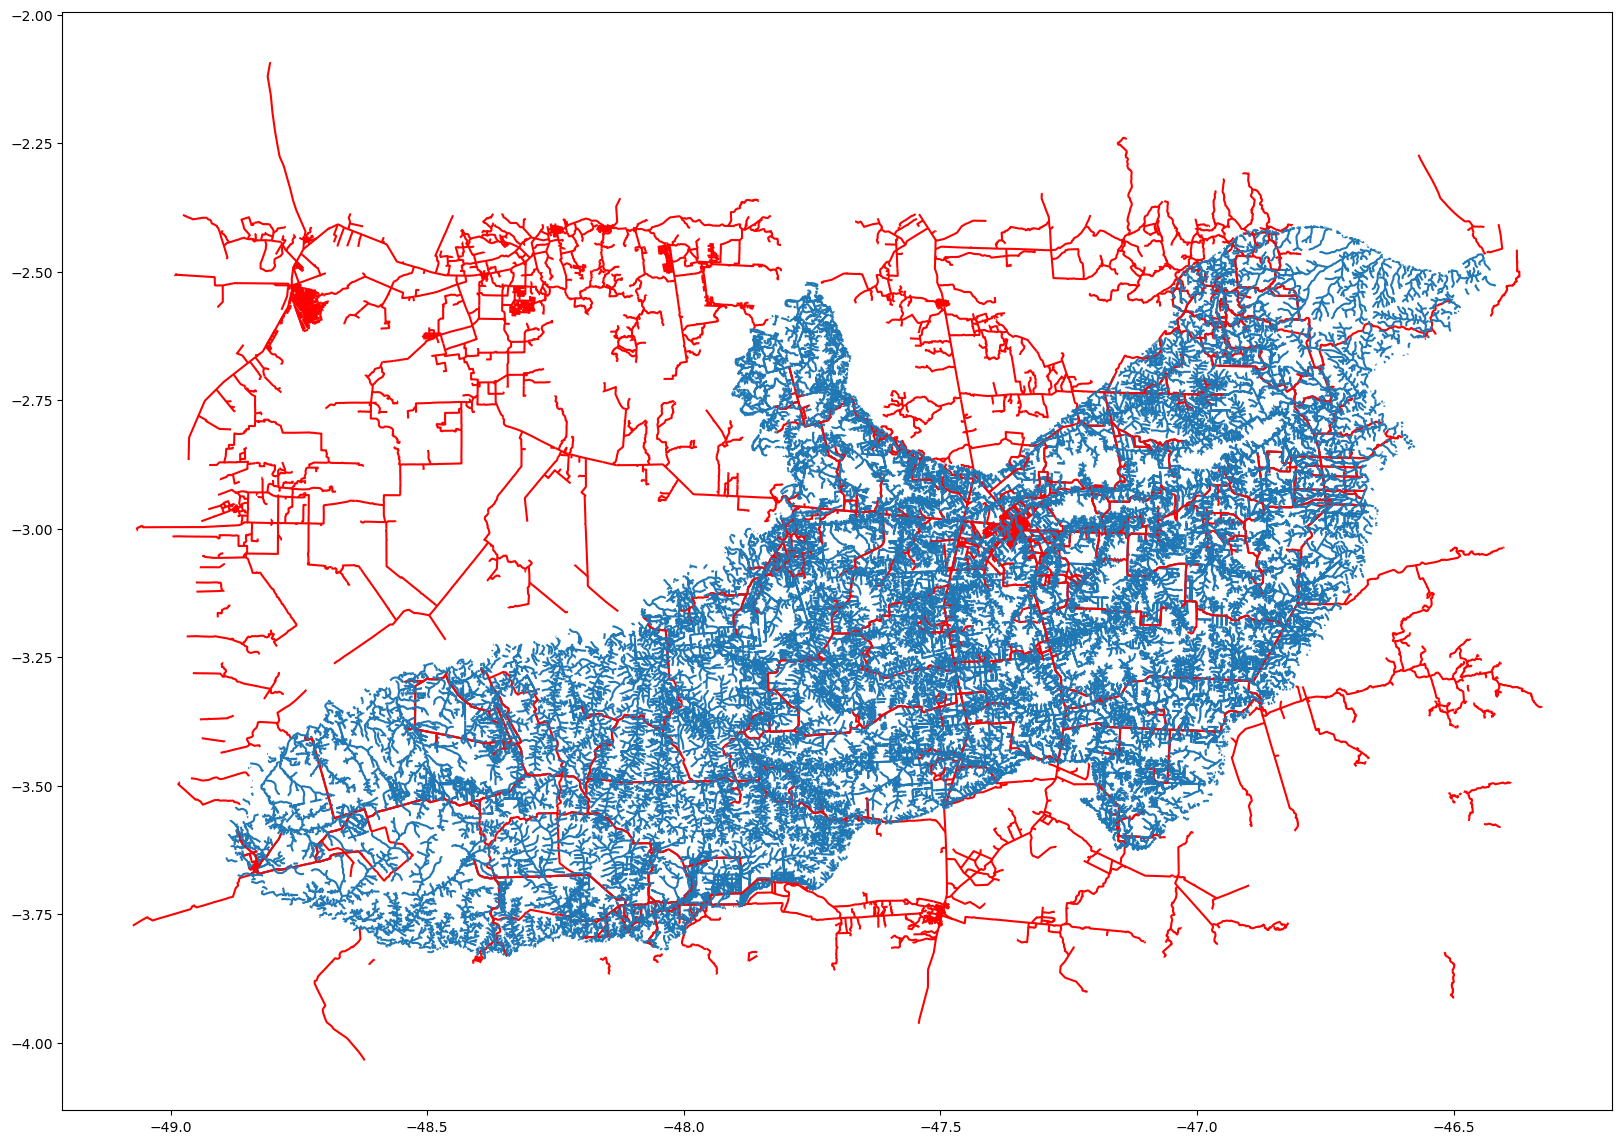

In [17]:
fig, ax = plt.subplots(figsize = (20, 20))
previsia_roads.plot(ax=ax)
osm_roads.plot(ax=ax,
               color = "red")
rivers.plot(ax=ax)